In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
import os

# EDA

## Exploration

In [21]:
def load_dataset() -> pd.DataFrame:
    columns = [
        "ID",
        "Age",
        "Gender",
        "Education",
        "Country",
        "Ethnicity",
        "Nscore",
        "Escore",
        "Oscore",
        "Ascore",
        "Cscore",
        "Impulsive",
        "SS",
        "Alcohol",
        "Amphet",
        "Amyl",
        "Benzos",
        "Caff",
        "Cannabis",
        "Choc",
        "Coke",
        "Crack",
        "Ecstasy",
        "Heroin",
        "Ketamine",
        "Legalh",
        "LSD",
        "Meth",
        "Mushrooms",
        "Nicotine",
        "Semer",
        "VSA",
    ]
    df = pd.read_csv(
        Path("drug_consumption/drug_consumption.data"),
        names=columns,
        index_col="ID",
    )
    return df

In [22]:
df = load_dataset()
df

,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,Cscore,...,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,Semer,VSA
ID,,,,,,,,,,,,,,,,,,,,,
1,0.49788,0.48246,-0.05921,0.96082,0.12600,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,...,CL0,CL0,CL0,CL0,CL0,CL0,CL0,CL2,CL0,CL0
2,-0.07854,-0.48246,1.98437,0.96082,-0.31685,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,CL4,CL0,CL2,CL0,CL2,CL3,CL0,CL4,CL0,CL0
3,0.49788,-0.48246,-0.05921,0.96082,-0.31685,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,CL0,CL0,CL0,CL0,CL0,CL0,CL1,CL0,CL0,CL0
4,-0.95197,0.48246,1.16365,0.96082,-0.31685,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,CL0,CL0,CL2,CL0,CL0,CL0,CL0,CL2,CL0,CL0
5,0.49788,0.48246,1.98437,0.96082,-0.31685,0.73545,-1.63340,-0.45174,-0.30172,1.30612,...,CL1,CL0,CL0,CL1,CL0,CL0,CL2,CL2,CL0,CL0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1884,-0.95197,0.48246,-0.61113,-0.57009,-0.31685,-1.19430,1.74091,1.88511,0.76096,-1.13788,...,CL0,CL0,CL0,CL3,CL3,CL0,CL0,CL0,CL0,CL5
1885,-0.95197,-0.48246,-0.61113,-0.57009,-0.31685,-0.24649,1.74091,0.58331,0.76096,-1.51840,...,CL2,CL0,CL0,CL3,CL5,CL4,CL4,CL5,CL0,CL0
1886,-0.07854,0.48246,0.45468,-0.57009,-0.31685,1.13281,-1.37639,-1.27553,-1.77200,-1.38502,...,CL4,CL0,CL2,CL0,CL2,CL0,CL2,CL6,CL0,CL0


In [23]:
df.describe()

,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,Cscore,Impulsive,SS
count,1885.00000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000,1885.000000
mean,0.03461,-0.000256,-0.003806,0.355542,-0.309577,0.000047,-0.000163,-0.000534,-0.000245,-0.000386,0.007216,-0.003292
std,0.87836,0.482588,0.950078,0.700335,0.166226,0.998106,0.997448,0.996229,0.997440,0.997523,0.954435,0.963701
min,-0.95197,-0.482460,-2.435910,-0.570090,-1.107020,-3.464360,-3.273930,-3.273930,-3.464360,-3.464360,-2.555240,-2.078480
25%,-0.95197,-0.482460,-0.611130,-0.570090,-0.316850,-0.678250,-0.695090,-0.717270,-0.606330,-0.652530,-0.711260,-0.525930
50%,-0.07854,-0.482460,-0.059210,0.960820,-0.316850,0.042570,0.003320,-0.019280,-0.017290,-0.006650,-0.217120,0.079870
75%,0.49788,0.482460,0.454680,0.960820,-0.316850,0.629670,0.637790,0.723300,0.760960,0.584890,0.529750,0.765400
max,2.59171,0.482460,1.984370,0.960820,1.907250,3.273930,3.273930,2.901610,3.464360,3.464360,2.901610,1.921730


### Re-structuring Categorical Data into Nominal or Ordinal Representations

In [24]:
# Nominal Data
def categorize_gender(gender: float) -> str:
    if gender == 0.48246:
        return "Female"
    elif gender == -0.48246:
        return "Male"
    else:
        return ""

def categorize_country(country: float) -> str:
    if country == -0.09765:
        return "Australia"
    elif country == 0.24923:
        return "Canada"
    elif country == -0.46841:
        return "New Zealand"
    elif country == -0.28519:
        return "Other"
    elif country == 0.21128:
        return "Ireland"
    elif country == 0.96082:
        return "United Kingdom"
    elif country == -0.57009:
        return "United States"
    else:
        return ""

def categorize_ethnicity(ethnicity: float) -> str:
    if ethnicity == -0.50212:
        return "Asian"
    elif ethnicity == -1.10702:
        return "Black"
    elif ethnicity == 1.90725:
        return "Mixed-Black/Asian"
    elif ethnicity == 0.12600:
        return "Mixed-White/Asian"
    elif ethnicity == -0.22166:
        return "Mixed-White/Black"
    elif ethnicity == 0.11440:
        return "Other"
    elif ethnicity == -0.31685:
        return "White"
    else:
        return ""

def categorize_drug(score: str) -> int:
    """
    Sends CL0 to 0 and CL6 to 6 to represent the ordinal classification
    :param score: Score from CL0 to CL6
    """
    return int(score[-1])

df["Gender"] = df["Gender"].apply(categorize_gender)
df["Country"] = df["Country"].apply(categorize_country)
df["Ethnicity"] = df["Ethnicity"].apply(categorize_ethnicity)

drug_cols = [
    "Alcohol", "Amphet", "Amyl", "Benzos", "Caff", "Cannabis",
    "Choc", "Coke", "Crack", "Ecstasy", "Heroin", "Ketamine",
    "Legalh", "LSD", "Meth", "Mushrooms", "Nicotine", "Semer", "VSA"
]
for col in drug_cols:
    df[col] = df[col].apply(categorize_drug)

### Cleaning out untrustworthy data

In [25]:
# Clean out all those who answered positively to Semer
semer_phoneys = df.loc[df["Semer"] != 0]
df.drop(semer_phoneys.index, inplace=True)
df.drop(columns="Semer", inplace=True)
df

,Age,Gender,Education,Country,Ethnicity,Nscore,Escore,Oscore,Ascore,Cscore,...,Crack,Ecstasy,Heroin,Ketamine,Legalh,LSD,Meth,Mushrooms,Nicotine,VSA
ID,,,,,,,,,,,,,,,,,,,,,
1,0.49788,Female,-0.05921,United Kingdom,Mixed-White/Asian,0.31287,-0.57545,-0.58331,-0.91699,-0.00665,...,0,0,0,0,0,0,0,0,2,0
2,-0.07854,Male,1.98437,United Kingdom,White,-0.67825,1.93886,1.43533,0.76096,-0.14277,...,0,4,0,2,0,2,3,0,4,0
3,0.49788,Male,-0.05921,United Kingdom,White,-0.46725,0.80523,-0.84732,-1.62090,-1.01450,...,0,0,0,0,0,0,0,1,0,0
4,-0.95197,Female,1.16365,United Kingdom,White,-0.14882,-0.80615,-0.01928,0.59042,0.58489,...,0,0,0,2,0,0,0,0,2,0
5,0.49788,Female,1.98437,United Kingdom,White,0.73545,-1.63340,-0.45174,-0.30172,1.30612,...,0,1,0,0,1,0,0,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1884,-0.95197,Female,-0.61113,United States,White,-1.19430,1.74091,1.88511,0.76096,-1.13788,...,0,0,0,0,3,3,0,0,0,5
1885,-0.95197,Male,-0.61113,United States,White,-0.24649,1.74091,0.58331,0.76096,-1.51840,...,0,2,0,0,3,5,4,4,5,0
1886,-0.07854,Female,0.45468,United States,White,1.13281,-1.37639,-1.27553,-1.77200,-1.38502,...,0,4,0,2,0,2,0,2,6,0


## Correlation Analysis

### Checking for redundant personality traits

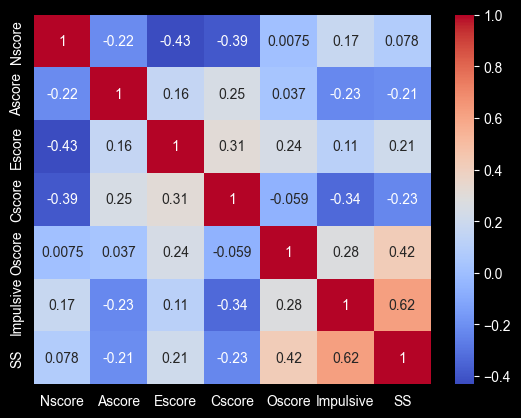

In [26]:
corr_df = df[["Nscore", "Ascore", "Escore", "Cscore", "Oscore", "Impulsive", "SS"]].corr(numeric_only=True, method="pearson")
sns.heatmap(corr_df, annot=True, cmap="coolwarm", fmt=".2g")
plt.show()

The pearson correlation between impulsive and SS is 0.6224995921301232 with p-val 7.568723691593961e-202


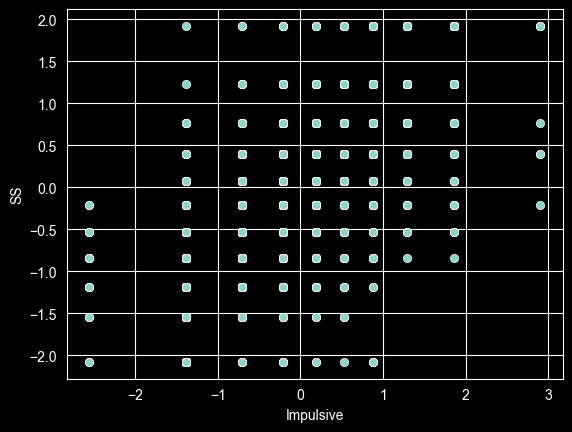

In [27]:
r, p = pearsonr(df["Impulsive"], df["SS"])
print(f"The pearson correlation between impulsive and SS is {r} with p-val {p}")
sns.scatterplot(data=df, x="Impulsive", y="SS")
plt.show()

The pearson correlation between Nscore and Escore is -0.4315353044006543 with p-val 5.349626162663832e-86


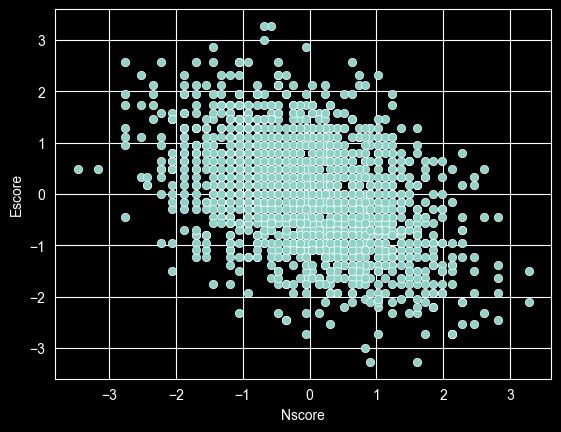

In [28]:
r, p = pearsonr(df["Nscore"], df["Escore"])
print(f"The pearson correlation between Nscore and Escore is {r} with p-val {p}")
sns.scatterplot(data=df, x="Nscore", y="Escore")
plt.show()

The pearson correlation between Nscore and Cscore is -0.39235421006337456 with p-val 4.056506841709671e-70


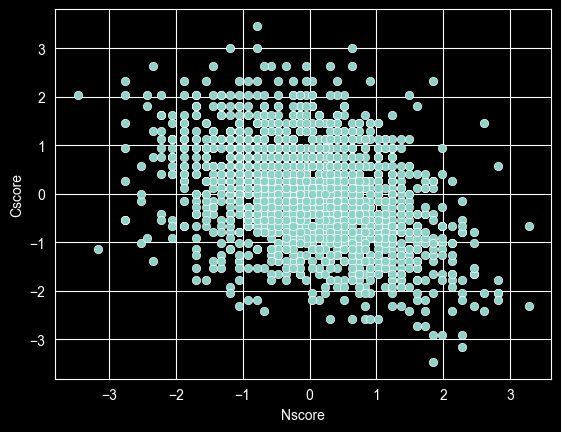

In [29]:
r, p = pearsonr(df["Nscore"], df["Cscore"])
print(f"The pearson correlation between Nscore and Cscore is {r} with p-val {p}")
sns.scatterplot(data=df, x="Nscore", y="Cscore")
plt.show()

The pearson correlation between Nscore and Ascore is -0.21777563909163322 with p-val 1.3813331065495579e-21


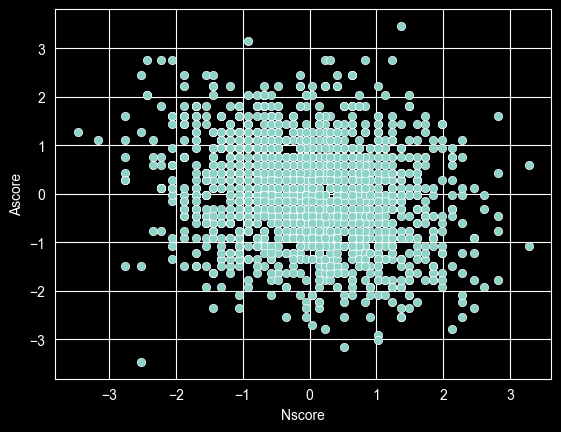

In [30]:
r, p = pearsonr(df["Nscore"], df["Ascore"])
print(f"The pearson correlation between Nscore and Ascore is {r} with p-val {p}")
sns.scatterplot(data=df, x="Nscore", y="Ascore")
plt.show()

The pearson correlation between SS and Oscore is 0.4194856784852297 with p-val 6.903098263413146e-81


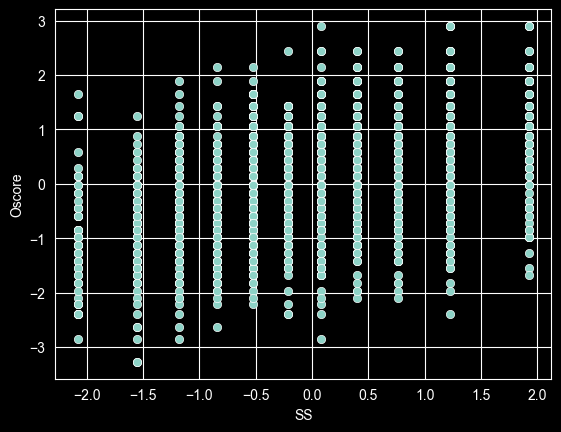

In [31]:
r, p = pearsonr(df["SS"], df["Oscore"])
print(f"The pearson correlation between SS and Oscore is {r} with p-val {p}")
sns.scatterplot(data=df, x="SS", y="Oscore")
plt.show()

The pearson correlation between Impulsive and Cscore is -0.33617518200199425 with p-val 8.111461892120058e-51


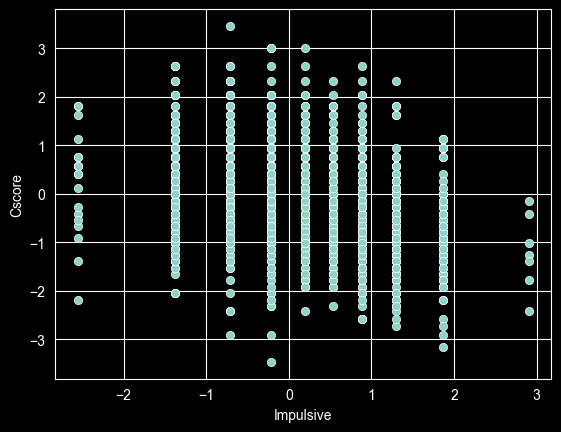

In [32]:
r, p = pearsonr(df["Impulsive"], df["Cscore"])
print(f"The pearson correlation between Impulsive and Cscore is {r} with p-val {p}")
sns.scatterplot(data=df, x="Impulsive", y="Cscore")
plt.show()

### Age to drug consumption patterns

In [33]:
age_df = df.drop(columns=["Nscore", "Escore", "Cscore", "Oscore", "Impulsive", "SS", "Ethnicity", "Country", "Education", "Ascore", "Gender"])
drug_cols = age_df.columns.tolist()
drug_cols.remove("Age")
for col in drug_cols:
    r, p = spearmanr(age_df["Age"], age_df[col])
    print(f"Spearman corr between age and {col} is {r:.2f}")

Spearman corr between age and Alcohol is 0.02
Spearman corr between age and Amphet is -0.21
Spearman corr between age and Amyl is -0.01
Spearman corr between age and Benzos is -0.09
Spearman corr between age and Caff is 0.14
Spearman corr between age and Cannabis is -0.45
Spearman corr between age and Choc is 0.08
Spearman corr between age and Coke is -0.17
Spearman corr between age and Crack is 0.00
Spearman corr between age and Ecstasy is -0.37
Spearman corr between age and Heroin is -0.04
Spearman corr between age and Ketamine is -0.19
Spearman corr between age and Legalh is -0.45
Spearman corr between age and LSD is -0.23
Spearman corr between age and Meth is -0.19
Spearman corr between age and Mushrooms is -0.29
Spearman corr between age and Nicotine is -0.23
Spearman corr between age and VSA is -0.16


### Correlation Analysis between continuous and ordinal categorical drug use

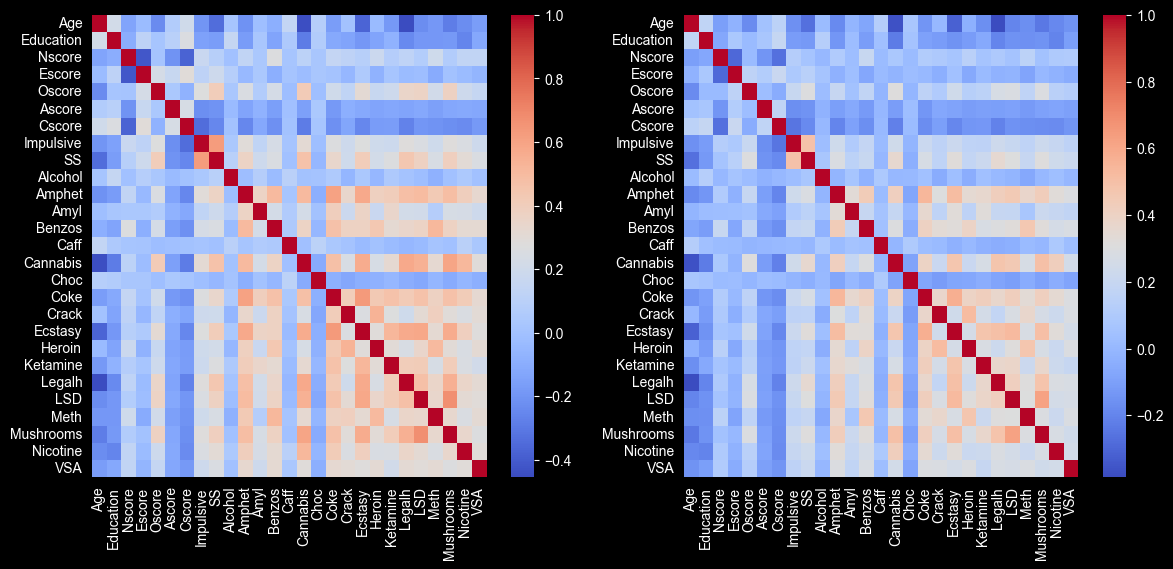

In [34]:
spear_corr_df = df.drop(columns=["Gender", "Ethnicity", "Country"]).corr(method="spearman")
kend_corr_df = df.drop(columns=["Gender", "Ethnicity", "Country"]).corr(method="kendall")
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
sns.heatmap(spear_corr_df,ax=axes[0], annot=False, cmap="coolwarm")
sns.heatmap(kend_corr_df,ax=axes[1], annot=False, cmap="coolwarm")
plt.show()

## Logistic Regression

In [39]:
new_df = df.drop(columns=["Age", "Gender", "Ethnicity", "Country", "Education", "SS", "Ascore", "Cscore", "Nscore", "Oscore", "Escore"])
data_np = new_df.to_numpy()